<a href="https://colab.research.google.com/github/uditjainofficial/smolvlm2-structured-food-extraction/blob/main/notebooks/VLM_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Install Dependencies**

In [5]:
!pip install -q -U transformers accelerate peft trl
!pip install -q -U datasets huggingface_hub
!pip install -q -U num2words gradio

In [6]:
from huggingface_hub import notebook_login
notebook_login()

#**Imports and device check**

In [7]:
import transformers
import trl
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Using device: {device}")
if device != "cuda":
    raise RuntimeError("No GPU detected - go to Runtime -> Change runtime type -> T4 GPU")

compute_dtype = torch.float16
print(f"[INFO] Using compute dtype: {compute_dtype} (T4-safe choice; DGX Spark can use bfloat16 instead)")

[INFO] Using device: cuda
[INFO] Using compute dtype: torch.float16 (T4-safe choice; DGX Spark can use bfloat16 instead)


#**Load the dataset**

In [8]:
from datasets import load_dataset
from PIL import Image

dataset = load_dataset("mrdbourke/FoodExtract-1k-Vision")
dataset

README.md:   0%|          | 0.00/2.29k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1510 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image_id', 'image_name', 'food101_class_name', 'food101_split', 'image_source', 'qwen3_vl_8b_yaml_out', 'qwen3_vl_inference_time', 'output_label_json', 'is_food', 'image'],
        num_rows: 1510
    })
})

In [9]:
example_sample = dataset["train"][0]
example_sample

{'image_id': '3233632',
 'image_name': '3233632.jpg',
 'food101_class_name': 'cheese_plate',
 'food101_split': 'train',
 'image_source': 'food101',
 'qwen3_vl_8b_yaml_out': 'point_of_view: 45-degree\ndishes:\n  - cheese plate\nfood_items:\n  - cheese wedge\n  - toast\n  - herb garnish\n  - dipping sauce\ndrink_items: []\ncontainers_and_utensils:\n  - white plate\n  - small white bowl\nattributes:\n  - sliced\n  - garnished\n  - served with accompaniments',
 'qwen3_vl_inference_time': 1.6110260486602783,
 'output_label_json': {'is_food': 1,
  'image_title': 'cheese plate',
  'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'],
  'drink_items': []},
 'is_food': 1,
 'image': <PIL.Image.Image image mode=RGB size=512x512>}

[INFO] Example desired output:
{'is_food': 1, 'image_title': 'cheese plate', 'food_items': ['toast', 'herb garnish', 'dipping sauce', 'cheese wedge'], 'drink_items': []}
[INFO] Example image input:


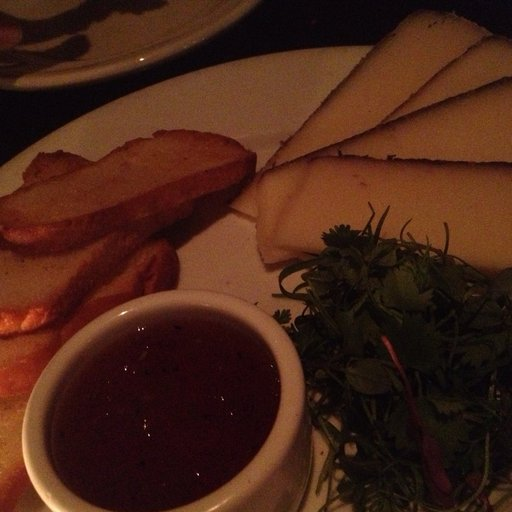

In [10]:
example_input = example_sample["image"]
example_output = example_sample["output_label_json"]

print(f"[INFO] Example desired output:\n{example_output}")
print(f"[INFO] Example image input:")
example_input

#**Format the dataset into chat-style messages (image + text -> JSON)**

In [11]:
# System message
SYSYTEM_MESSAGE = """You are an expert food and drink image extractor.
You provide structured data to visual inputs classifying them as edible food/drink or not.
As well as titling the image with a simple food/drink related caption.
Finally you extract any and all visible food/drink items to lists.
"""

# User prompt with image input as well as desired output
USER_PROMPT = """Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.

Only return valid JSON in the following form:

```json
{
  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)
  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present
  'food_items': [], # list[str] - list of visible edible food item nouns
  'drink_items': [] # list[str] - list of visible edible drink item nouns
}
```
"""

# Create helper function to map our input/output samples to conversational format
def format_data(sample):
    return {
        "messages": [

            # Message 0 - [SYSTEM] System Prompt (setting the scene)
            {
                "role": "system",
                "content": [{"type": "text", "text": SYSYTEM_MESSAGE}]
            },

            # Message 1 - [USER] User input (image + prompt pair)
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": sample["image"],
                    },
                    {
                        "type": "text",
                        "text": USER_PROMPT
                    }
                ],
            },

            # Message 2 - [MODEL] Ideal model output (e.g. our structured data format)
            {
                "role": "assistant",
                "content": [{"type": "text", "text": sample["output_label_json"]}]
            }
        ]
    }

formatted_sample = format_data(sample=example_sample)
formatted_sample

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]},
  {'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=512x512>},
    {'type': 'text',
     'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods pr

In [12]:
# Format each item in the original dataset, keeping the PIL image type
dataset_processed = [format_data(sample) for sample in dataset["train"]]
dataset_processed[0]

{'messages': [{'role': 'system',
   'content': [{'type': 'text',
     'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]},
  {'role': 'user',
   'content': [{'type': 'image',
     'image': <PIL.Image.Image image mode=RGB size=512x512>},
    {'type': 'text',
     'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods pr

#**Train / validation split**

In [13]:
import random
from pprint import pprint

random.seed(42)
dataset_shuffled = random.sample(dataset_processed, k=len(dataset_processed))

# Use 80% split for training, 20% for validation
train_split = round(0.8 * len(dataset_shuffled))

train_dataset = dataset_shuffled[:train_split]
val_dataset = dataset_shuffled[train_split:]
print(f"[INFO] Number of total samples: {len(dataset_processed)}")
print(f"[INFO] Number of train samples: {len(train_dataset)}")
print(f"[INFO] Number of eval samples: {len(val_dataset)}")

print(f"\n[INFO] Example training sample:\n")
pprint(train_dataset[0])
print(f"\n[INFO] Example validation sample:\n")
pprint(val_dataset[0])

[INFO] Number of total samples: 1510
[INFO] Number of train samples: 1208
[INFO] Number of eval samples: 302

[INFO] Example training sample:

{'messages': [{'content': [{'text': 'You are an expert food and drink image '
                                    'extractor.\n'
                                    'You provide structured data to visual '
                                    'inputs classifying them as edible '
                                    'food/drink or not.\n'
                                    'As well as titling the image with a '
                                    'simple food/drink related caption.\n'
                                    'Finally you extract any and all visible '
                                    'food/drink items to lists.\n',
                            'type': 'text'}],
               'role': 'system'},
              {'content': [{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x678 at 0x7BEB9B731370>,
                     

In [14]:
# We only want the model to see the system/user inputs (not the desired response)
example_base_model_input = dataset_processed[0]["messages"][:2]
example_base_model_input

[{'role': 'system',
  'content': [{'type': 'text',
    'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]},
 {'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.Image.Image image mode=RGB size=512x512>},
   {'type': 'text',
    'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present\n  'food_items

#**Sanity-check the base (not fine-tuned) model**
We load a quick pipeline first just to see how the base model behaves before we fine-tune anything.

In [15]:
from transformers import pipeline

MODEL_ID = "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"

pipe = pipeline(
    "image-text-to-text",
    model=MODEL_ID,
    device="cuda",
    dtype=compute_dtype  # float16 on T4
)

config.json:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


model.safetensors:   0%|          | 0.00/2.03G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/4.74k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/868 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.55M [00:00<?, ?B/s]

In [16]:
# Test the base model on an example input image
base_model_output = pipe(text=example_base_model_input,
                         max_new_tokens=256)

print(f'[INFO] Base model input (text only):\n{example_base_model_input}\n')
print(f'[INFO] Base model output:\n{base_model_output[0]["generated_text"][-1]["content"]}\n')
print(f'[INFO] Desired output:\n{dataset_processed[0]["messages"][-1]["content"][0]["text"]}')

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Base model input (text only):
[{'role': 'system', 'content': [{'type': 'text', 'text': 'You are an expert food and drink image extractor.\nYou provide structured data to visual inputs classifying them as edible food/drink or not.\nAs well as titling the image with a simple food/drink related caption.\nFinally you extract any and all visible food/drink items to lists.\n'}]}, {'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=512x512 at 0x7BED27B23860>}, {'type': 'text', 'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank

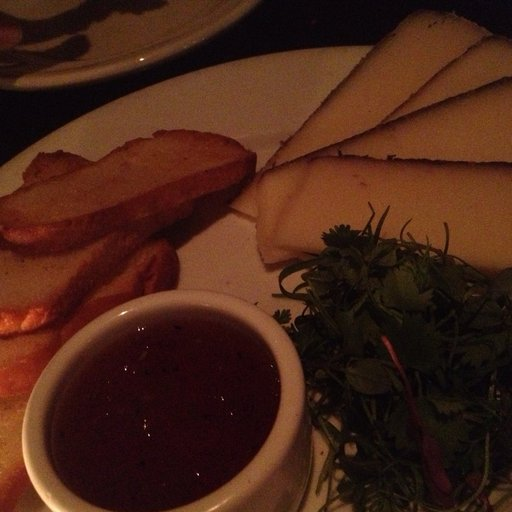

In [17]:
# Check example input image
example_base_model_input[1]["content"][0]["image"]

In [18]:
# Free up VRAM before loading the trainable copy of the model
del pipe
torch.cuda.empty_cache()

#**Load the trainable model + processor**

In [19]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

print(f"[INFO] Using model: {MODEL_ID}")

model_kwargs = dict(
    attn_implementation="eager",
    dtype=torch.float32,
    device_map="auto"
)

model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, **model_kwargs)
processor = AutoProcessor.from_pretrained(MODEL_ID)

[INFO] Using model: HuggingFaceTB/SmolVLM2-500M-Video-Instruct


Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

In [20]:
# Inspect our model's architecture
model

SmolVLMForConditionalGeneration(
  (model): SmolVLMModel(
    (vision_model): SmolVLMVisionTransformer(
      (embeddings): SmolVLMVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): SmolVLMEncoder(
        (layers): ModuleList(
          (0-11): 12 x SmolVLMEncoderLayer(
            (self_attn): SmolVLMVisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
            (mlp): SmolVLMVisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, out_feature

In [21]:
# Apply the chat template and run one forward generation with the raw model
example_chat_template_input = processor.apply_chat_template(
    [example_base_model_input[1]],
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(device)

input_len = example_chat_template_input["input_ids"].shape[-1]
print(f"[INFO] Input length: {input_len}")

with torch.no_grad():
    generation_output_full = model.generate(**example_chat_template_input,
                                            max_new_tokens=256,
                                            do_sample=False)
    generation_output_short = generation_output_full[0][input_len:]

decoded_outputs = processor.decode(generation_output_short,
                                   skip_special_tokens=True)

print("\n"+"-"*50+"\n")
print(f"[INFO] Raw token input to our model:\n")
print(example_chat_template_input["input_ids"][0])
print("\n"+"-"*50+"\n")
print(f"[INFO] Raw pixel values input to our model:\n")
print(example_chat_template_input["pixel_values"][0])
print("\n"+"-"*50+"\n")
print(f"[INFO] Human-readable input:\n")
print(processor.decode(example_chat_template_input["input_ids"][0]))
print("\n"+"-"*50+"\n")
print(f"[INFO] Model output:\n")
print(decoded_outputs)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[INFO] Input length: 1310

--------------------------------------------------

[INFO] Raw token input to our model:

tensor([    1, 11126,    42,  ...,  9519,  9531,    42], device='cuda:0')

--------------------------------------------------

[INFO] Raw pixel values input to our model:

tensor([[[[-0.3804, -0.3804, -0.3804,  ..., -0.8431, -0.8431, -0.8353],
          [-0.3804, -0.3804, -0.3804,  ..., -0.8353, -0.8353, -0.8275],
          [-0.3804, -0.3804, -0.3804,  ..., -0.8353, -0.8353, -0.8275],
          ...,
          [-0.9216, -0.9216, -0.9216,  ..., -0.0667, -0.0667, -0.0745],
          [-0.9216, -0.9216, -0.9216,  ..., -0.0667, -0.0667, -0.0745],
          [-0.9137, -0.9137, -0.9137,  ..., -0.0745, -0.0745, -0.0745]],

         [[-0.6549, -0.6549, -0.6549,  ..., -0.9216, -0.9216, -0.9059],
          [-0.6549, -0.6549, -0.6549,  ..., -0.9137, -0.9137, -0.8980],
          [-0.6549, -0.6549, -0.6549,  ..., -0.9137, -0.9137, -0.8980],
          ...,
          [-0.9608, -0.9608, -0

#**Freeze the vision encoder (train only the language model part)**

In [22]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    return total, trainable, frozen

total_params, trainable_params, frozen_params = count_parameters(model)
print(f"[INFO] Params Total (before freezing the vision model): {total_params:,} | Trainable: {trainable_params:,} | Frozen: {frozen_params:,}")

# Freeze the vision encoder
for param in model.model.vision_model.parameters():
    param.requires_grad = False

total_params, trainable_params, frozen_params = count_parameters(model)
print(f"[INFO] Params Total (after freezing the vision model): {total_params:,} | Trainable: {trainable_params:,} | Frozen: {frozen_params:,}")

[INFO] Params Total (before freezing the vision model): 507,482,304 | Trainable: 507,482,304 | Frozen: 0
[INFO] Params Total (after freezing the vision model): 507,482,304 | Trainable: 421,049,280 | Frozen: 86,433,024


#**Data collator**

In [23]:
def convert_message_to_list_of_images(messages: list[dict]) -> list[Image.Image]:
    """Helper function to turn our message samples into lists of images."""
    image_inputs = []

    for msg in messages:
        content = msg.get("content", [])
        if not isinstance(content, list):
            content = [content]

        for element in content:
            if isinstance(element, dict) and (
                "image" in element or element.get("type") == "image"
            ):
                if "image" in element:
                    image = element["image"]
                else:
                    image = element
                image_inputs.append(image.convert("RGB"))

    return image_inputs

def collate_fn(examples):
    """Helper function to stack together image + text pairs into batches."""

    texts = []
    images = []

    for example in examples:
        image_inputs = convert_message_to_list_of_images(example["messages"])
        text = processor.apply_chat_template(
            example["messages"], add_generation_prompt=False, tokenize=False
        )
        texts.append(text.strip())
        images.append(image_inputs)

    batch_input = processor(text=texts,
                            images=images,
                            return_tensors="pt",
                            padding=True)

    # Labels are the input_ids, mask padding + image placeholder tokens from the loss
    labels = batch_input["input_ids"].clone()

    image_token_id = processor.tokenizer.convert_tokens_to_ids("<image>")

    labels[labels == processor.tokenizer.pad_token_id] = -100
    labels[labels == image_token_id] = -100

    batch_input["labels"] = labels

    return batch_input

image_token_id = processor.tokenizer.convert_tokens_to_ids("<image>")
print(f"[INFO] SmolVLM2 image_token_id: {image_token_id} (masked out of the loss, it's just a placeholder)")

[INFO] SmolVLM2 image_token_id: 49190 (masked out of the loss, it's just a placeholder)


#**Training config**

In [24]:
from trl import SFTConfig

training_args = SFTConfig(
    output_dir="smolvlm2-500m-FoodExtract-Vision-v1-colab-t4",
    num_train_epochs=4,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    fp16=False,
    bf16=False,
    save_total_limit=1,
    max_grad_norm=1.0,
    warmup_ratio=0.03,
    lr_scheduler_type="constant",
    push_to_hub=False,
    report_to="none",
    gradient_checkpointing_kwargs={"use_reentrant": False},
    dataset_text_field="",
    dataset_kwargs={"skip_prepare_dataset": True},
    load_best_model_at_end=True,
    remove_unused_columns=False
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


#**Train**

In [25]:
from trl import SFTTrainer

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset[:100],
    eval_dataset=val_dataset[:50],
    processing_class=processor,
    data_collator=collate_fn
)

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 49279, 'bos_token_id': 1, 'pad_token_id': 2}.
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `process

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,No log,0.146237,0.158366,126857.000000,0.971663
2,No log,0.115489,0.103300,253714.000000,0.972172
3,No log,0.122785,0.066654,380571.000000,0.975056
4,0.331828,0.129351,0.062722,507428.000000,0.973656


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform

...

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`
[transform

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=28, training_loss=0.2987115164952619, metrics={'train_runtime': 3792.9897, 'train_samples_per_second': 0.105, 'train_steps_per_second': 0.007, 'total_flos': 1398635179024896.0, 'train_loss': 0.2987115164952619, 'epoch': 4.0})

In [26]:
# Save the model to disk
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

#**Plot training / validation loss**

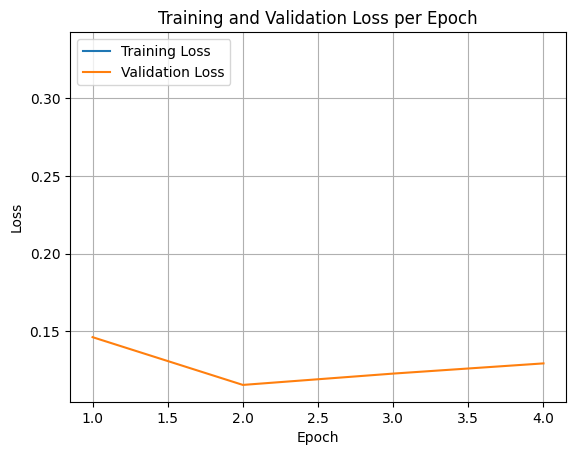

In [27]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

plt.plot(epoch_train, train_losses, label="Training Loss")
plt.plot(epoch_eval, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

#**Free GPU memory before comparing base vs. fine-tuned models**

In [28]:
import gc

del model
del trainer
gc.collect()
torch.cuda.empty_cache()

In [29]:
CHECKPOINT_DIR_NAME = training_args.output_dir
print(f"[INFO] Using fine-tuned checkpoint: {CHECKPOINT_DIR_NAME}")

[INFO] Using fine-tuned checkpoint: smolvlm2-500m-FoodExtract-Vision-v1-colab-t4


#**Compare the base (pre-trained) model vs. the fine-tuned model**

In [30]:
from transformers import pipeline

# Load the base model ("pt_pipe" = "pretrained pipeline")
pt_pipe = pipeline(
    "image-text-to-text",
    model=MODEL_ID,
    dtype=compute_dtype
)
pt_pipe.model.generation_config.do_sample = False
pt_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id

# Load the fine-tuned model
ft_pipe = pipeline(
    "image-text-to-text",
    model=CHECKPOINT_DIR_NAME,
    dtype=compute_dtype
)
ft_pipe.model.generation_config.do_sample = True
ft_pipe.model.generation_config.pad_token_id = processor.tokenizer.eos_token_id

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

In [31]:
pt_pipe.device, ft_pipe.device

(device(type='cuda', index=0), device(type='cuda', index=0))

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[INFO] Example model input:
{'role': 'user', 'content': [{'type': 'image', 'image': <PIL.Image.Image image mode=RGB size=512x512 at 0x7BEBB5670200>}, {'type': 'text', 'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present\n  'food_items': [], # list[str] - list of visible edible food item nouns\n  'drink_items': [] # list[str] - list of visible edible drink item nouns\n}\n```\n"}]}

[INFO] Example model ideal output:
{'is_food': 1, 'image_title': 'egg drop soup', 'food_items': ['broth', 'chicken (chopped)', 'mushroom', 'egg whites (shredded)', 'chili 

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`



[INFO] Generated output text from pre-trained model:
 [
]



[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[INFO] Generated output text from fine-tuned model:
 {'is_food': 1, 'image_title': 'nori soup', 'food_items': ['sliced nori', 'red onion', 'green onion', 'chili oil', 'chili oil spray', 'chili oil drizzle'], 'drink_items': []}

[INFO] Input image:


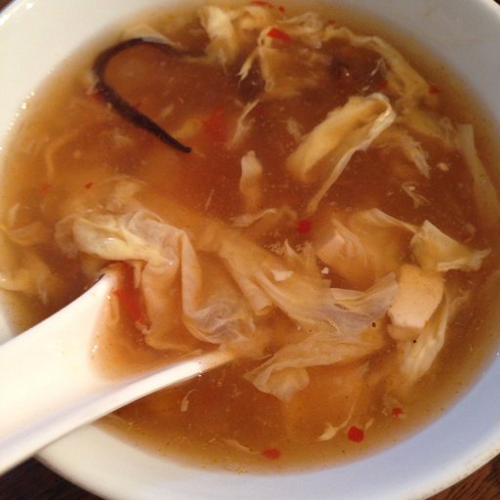

In [32]:
import random

random_val_sample = random.choice(val_dataset)
random_val_sample_model_input = random_val_sample["messages"][1]
random_val_sample_image = random_val_sample_model_input["content"][0]["image"]
random_val_sample_model_output = random_val_sample["messages"][-1]

ideal_output_text = random_val_sample_model_output["content"][0]["text"]

print(f"[INFO] Example model input:\n{random_val_sample_model_input}")
print()
print(f"[INFO] Example model ideal output:\n{ideal_output_text}")

pt_pipe_output = pt_pipe(text=[random_val_sample_model_input],
                         max_new_tokens=256)
pt_pipe_output_text = pt_pipe_output[0]["generated_text"][-1]["content"]
print(f"\n[INFO] Generated output text from pre-trained model:\n{pt_pipe_output_text}\n")

ft_pipe_output = ft_pipe(text=[random_val_sample_model_input],
                         max_new_tokens=256)
ft_pipe_output_text = ft_pipe_output[0]["generated_text"][-1]["content"]
print(f"\n[INFO] Generated output text from fine-tuned model:\n{ft_pipe_output_text}\n")

print(f"[INFO] Input image:")
random_val_sample_image.resize(size=(500, 500))

#**Push the fine-tuned model to the Hugging Face Hub**

In [33]:
from huggingface_hub import HfApi, create_repo
api = HfApi()
repo_id = "udit74j/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1"
create_repo(repo_id, repo_type="model", exist_ok=True)
api.upload_folder(
    folder_path="./smolvlm2-500m-FoodExtract-Vision-v1-colab-t4/",
    repo_id=repo_id,
    repo_type="model"
)

CommitInfo(commit_url='https://huggingface.co/udit74j/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1/commit/ddf338b5b0904b4b7a5f4766aaaca8bc269bdf5e', commit_message='Upload folder using huggingface_hub', commit_description='', oid='ddf338b5b0904b4b7a5f4766aaaca8bc269bdf5e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/udit74j/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='udit74j/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1'), pr_revision=None, pr_num=None)

#**Build a Gradio demo**

In [36]:
%%writefile demos/FoodExtract-Vision-v1/requirements.txt
num2words
transformers
torch
accelerate
gradio
torchvision

Writing demos/FoodExtract-Vision-v1/requirements.txt


In [35]:
!mkdir -p demos/FoodExtract-Vision-v1

In [37]:
%%writefile demos/FoodExtract-Vision-v1/app.py
import torch
import gradio as gr

import spaces
from transformers import pipeline

BASE_MODEL_ID = "HuggingFaceTB/SmolVLM2-500M-Video-Instruct"
FINE_TUNED_MODEL_ID = "uditj74/FoodExtract-Vision-SmolVLM2-500M-fine-tune-v1"  # change to your repo
OUTPUT_TOKENS = 256

print(f"[INFO] Loading Original Model")
original_pipeline = pipeline(
    "image-text-to-text",
    model=BASE_MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto"
)

print(f"[INFO] Loading Fine-tuned Model")
ft_pipe = pipeline(
    "image-text-to-text",
    model=FINE_TUNED_MODEL_ID,
    dtype=torch.bfloat16,
    device_map="auto"
)

def create_message(input_image):
    return [{'role': 'user',
 'content': [{'type': 'image',
   'image': input_image},
  {'type': 'text',
   'text': "Classify the given input image into food or not and if edible food or drink items are present, extract those to a list. If no food/drink items are visible, return empty lists.\n\nOnly return valid JSON in the following form:\n\n```json\n{\n  'is_food': 0, # int - 0 or 1 based on whether food/drinks are present (0 = no foods visible, 1 = foods visible)\n  'image_title': '', # str - short food-related title for what foods/drinks are visible in the image, leave blank if no foods present\n  'food_items': [], # list[str] - list of visible edible food item nouns\n  'drink_items': [] # list[str] - list of visible edible drink item nouns\n}\n```\n"}]}]

@spaces.GPU
def extract_foods_from_image(input_image):
    input_image = input_image.resize(size=(512, 512))
    input_message = create_message(input_image=input_image)

    original_pipeline_output = original_pipeline(text=[input_message],
                                                 max_new_tokens=OUTPUT_TOKENS)
    outputs_pretrained = original_pipeline_output[0][0]["generated_text"][-1]["content"]

    ft_pipe_output = ft_pipe(text=[input_message],
                             max_new_tokens=OUTPUT_TOKENS)
    outputs_fine_tuned = ft_pipe_output[0][0]["generated_text"][-1]["content"]

    return outputs_pretrained, outputs_fine_tuned

demo_title = "Food/Drink Extractor - fine-tuned SmolVLM2-500M"
demo_description = "Extract food and drink items in a structured JSON format from images."

demo = gr.Interface(
    fn=extract_foods_from_image,
    inputs=gr.Image(type="pil"),
    title=demo_title,
    description=demo_description,
    outputs=[gr.Textbox(lines=4, label="Original Model (not fine-tuned)"),
             gr.Textbox(lines=4, label="Fine-tuned Model")],
)

if __name__ == "__main__":
    demo.launch(share=True)

Writing demos/FoodExtract-Vision-v1/app.py
